<a href="https://colab.research.google.com/github/rjlobosco/modelagem_computacional/blob/main/Simulacao_Adveccao_Difusao_Pluma_Cumbica(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação didática da dispersão de fumaça: advecção–difusão

Este notebook demonstra como um campo de vento transporta e espalha uma concentração de fumaça. A simulação usa a equação bidimensional de advecção–difusão e as componentes diárias `u10` e `v10` fornecidas para a célula mais próxima de Cumbica, em 27/08/2026.

> **Escopo:** modelo simplificado para ensino. Os dados são médias diárias numa grade meteorológica regional. A simulação não reconstrói o acidente nem estima concentrações reais: faltam, entre outros dados, emissão, altura e temperatura da fonte, estabilidade atmosférica, turbulência local e vento horário.

## 1. Modelo físico

Considere (C(x,y,t)), uma concentração relativa de fumaça em um plano horizontal. Usaremos

\[
\frac{\partial C}{\partial t}+u\frac{\partial C}{\partial x}+v\frac{\partial C}{\partial y}
=K\left(\frac{\partial^2 C}{\partial x^2}+\frac{\partial^2 C}{\partial y^2}\right)+S(x,y),
\]

onde (u,v) são as componentes do vento, (K) é uma difusividade turbulenta efetiva e (S) representa uma fonte contínua idealizada. Aqui (x) aponta para leste e (y) para norte. Assim, componentes negativas indicam transporte para oeste e sul.

## 2. Bibliotecas e parâmetros do vento

Se os dois CSVs estiverem disponíveis no ambiente, o código os lê e seleciona a célula mais próxima da localização aproximada de Cumbica. Se não estiverem, usa os valores já calculados a partir dos arquivos anexados.

**No Google Colab:** execute a célula seguinte e selecione os dois arquivos CSV. Se preferir, faça upload manual deles pelo painel lateral de arquivos; o notebook também usa valores demonstrativos embutidos caso os CSVs não estejam disponíveis.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# No Colab, opcionalmente envie os dois CSVs diretamente do computador.
# Se cancelar ou não tiver os arquivos, o notebook usará os valores de exemplo abaixo.
try:
    from google.colab import files
    if not (Path("10m_u_component_wind.csv").exists() and Path("10m_v_component_of_wind_0_daily-mean.csv").exists()):
        print("Selecione os CSVs u10 e v10. Você também pode cancelar para usar os valores demonstrativos.")
        uploaded = files.upload()
except ImportError:
    print("Ambiente fora do Colab: coloque os CSVs na pasta do notebook para carregá-los automaticamente.")

# Localização aproximada de Cumbica, usada somente para escolher a célula próxima.
LAT_CUMBICA, LON_CUMBICA = -23.43, -46.47
U_CSV = Path("10m_u_component_wind.csv")
V_CSV = Path("10m_v_component_of_wind_0_daily-mean.csv")

if U_CSV.exists() and V_CSV.exists():
    u_df = pd.read_csv(U_CSV)
    v_df = pd.read_csv(V_CSV)
    met = u_df.merge(v_df, on=["valid_time", "latitude", "longitude", "number"])
    met["dist2"] = (met["latitude"]-LAT_CUMBICA)**2 + (met["longitude"]-LON_CUMBICA)**2
    met_row = met.loc[met["dist2"].idxmin()]
    u10, v10 = float(met_row["u10"]), float(met_row["v10"])
    data_date = str(met_row["valid_time"])
    grid_lat, grid_lon = float(met_row["latitude"]), float(met_row["longitude"])
else:
    # Valores da célula mais próxima: lat=-23.50, lon=-46.50, em 27/08/2026.
    u10, v10 = -0.96089363, -1.68118480
    data_date, grid_lat, grid_lon = "2026-08-27", -23.50, -46.50

speed = np.hypot(u10, v10)
print(f"Data: {data_date}")
print(f"Célula meteorológica: ({grid_lat:.2f}°, {grid_lon:.2f}°)")
print(f"u10 = {u10:.2f} m/s; v10 = {v10:.2f} m/s")
print(f"Velocidade horizontal = {speed:.2f} m/s")

Data: 2026-08-27
Célula meteorológica: (-23.50°, -46.50°)
u10 = -0.96 m/s; v10 = -1.68 m/s
Velocidade horizontal = 1.94 m/s


## 3. Domínio, fonte e estabilidade numérica

O domínio é um plano de 3 km por 3 km, com a fonte perto do centro. A emissão contínua é representada por uma gaussiana estreita. O vento é uniforme e constante no espaço e no tempo. O método explícito usa diferenças upwind para advecção e diferenças centrais para difusão.

In [34]:
# Domínio espacial (m)
Lx = Ly = 3000.0
dx = dy = 20.0
x = np.arange(0, Lx + dx, dx)
y = np.arange(0, Ly + dy, dy)
X, Y = np.meshgrid(x, y)

# Parâmetros didáticos ajustáveis
K = 20.0                 # difusividade efetiva (m^2/s), escolhida para demonstração
dt = 2.0                 # passo temporal (s)
t_final = 600.0          # duração da simulação (s)
source_x, source_y = 1500.0, 1500.0
source_sigma = 45.0      # largura da fonte gaussiana (m)
source_strength = 0.025  # intensidade relativa por segundo

# Verificações de estabilidade para o esquema explícito (condições conservadoras)
cfl_adv = abs(u10)*dt/dx + abs(v10)*dt/dy
cfl_diff = 2*K*dt*(1/dx**2 + 1/dy**2)
print(f"CFL advectivo = {cfl_adv:.3f} (manter <= 1)")
print(f"Número difusivo = {cfl_diff:.3f} (manter <= 1)")
if cfl_adv > 1 or cfl_diff > 1:
    raise ValueError("Esquema explícito potencialmente instável: reduza dt ou aumente dx/dy.")

source = np.exp(-((X-source_x)**2 + (Y-source_y)**2)/(2*source_sigma**2))
source /= source.max()
C = np.zeros_like(X, dtype=float)

CFL advectivo = 0.264 (manter <= 1)
Número difusivo = 0.400 (manter <= 1)


## 4. Discretização

Para cada passo, calculamos derivadas advectivas upwind segundo o sinal de (u) e (v), e o Laplaciano por diferenças centrais. A fonte é adicionada em todos os passos. Nas bordas, adotamos concentração nula (sumidouro numérico), portanto o domínio deve ser amplo o suficiente para que a pluma não alcance as bordas durante a demonstração.

In [35]:
def advance(C, u, v, K, dt, dx, dy, source, source_strength):
    """Avança um passo da equação 2D de advecção-difusão explícita."""
    Cn = C.copy()
    dCdx = np.zeros_like(C)
    dCdy = np.zeros_like(C)

    # Upwind em x
    if u >= 0:
        dCdx[:, 1:-1] = (C[:, 1:-1] - C[:, :-2]) / dx
    else:
        dCdx[:, 1:-1] = (C[:, 2:] - C[:, 1:-1]) / dx
    # Upwind em y (índice crescente corresponde a norte)
    if v >= 0:
        dCdy[1:-1, :] = (C[1:-1, :] - C[:-2, :]) / dy
    else:
        dCdy[1:-1, :] = (C[2:, :] - C[1:-1, :]) / dy

    lap = np.zeros_like(C)
    lap[1:-1, 1:-1] = (
        (C[1:-1, 2:] - 2*C[1:-1, 1:-1] + C[1:-1, :-2]) / dx**2
        + (C[2:, 1:-1] - 2*C[1:-1, 1:-1] + C[:-2, 1:-1]) / dy**2
    )
    Cn[1:-1, 1:-1] = C[1:-1, 1:-1] + dt * (
        -u*dCdx[1:-1, 1:-1] - v*dCdy[1:-1, 1:-1]
        + K*lap[1:-1, 1:-1] + source_strength*source[1:-1, 1:-1]
    )
    # Limita pequenos negativos de arredondamento numérico
    return np.maximum(Cn, 0.0)

## 5. Executar e guardar snapshots

A escala é relativa e normalizada apenas para facilitar a visualização. Cada snapshot registra o campo de concentração em um instante.

In [36]:
times = [0.0]
snapshots = [C.copy()]
n_steps = int(round(t_final/dt))
snapshot_every = max(1, n_steps//6)

for n in range(1, n_steps+1):
    C = advance(C, u10, v10, K, dt, dx, dy, source, source_strength)
    if n % snapshot_every == 0 or n == n_steps:
        times.append(n*dt)
        snapshots.append(C.copy())

print(f"Snapshots armazenados: {len(snapshots)}")
print(f"Concentração máxima final (escala relativa): {snapshots[-1].max():.3f}")

Snapshots armazenados: 7
Concentração máxima final (escala relativa): 0.923


## 6. Visualizar a dispersão em diferentes tempos

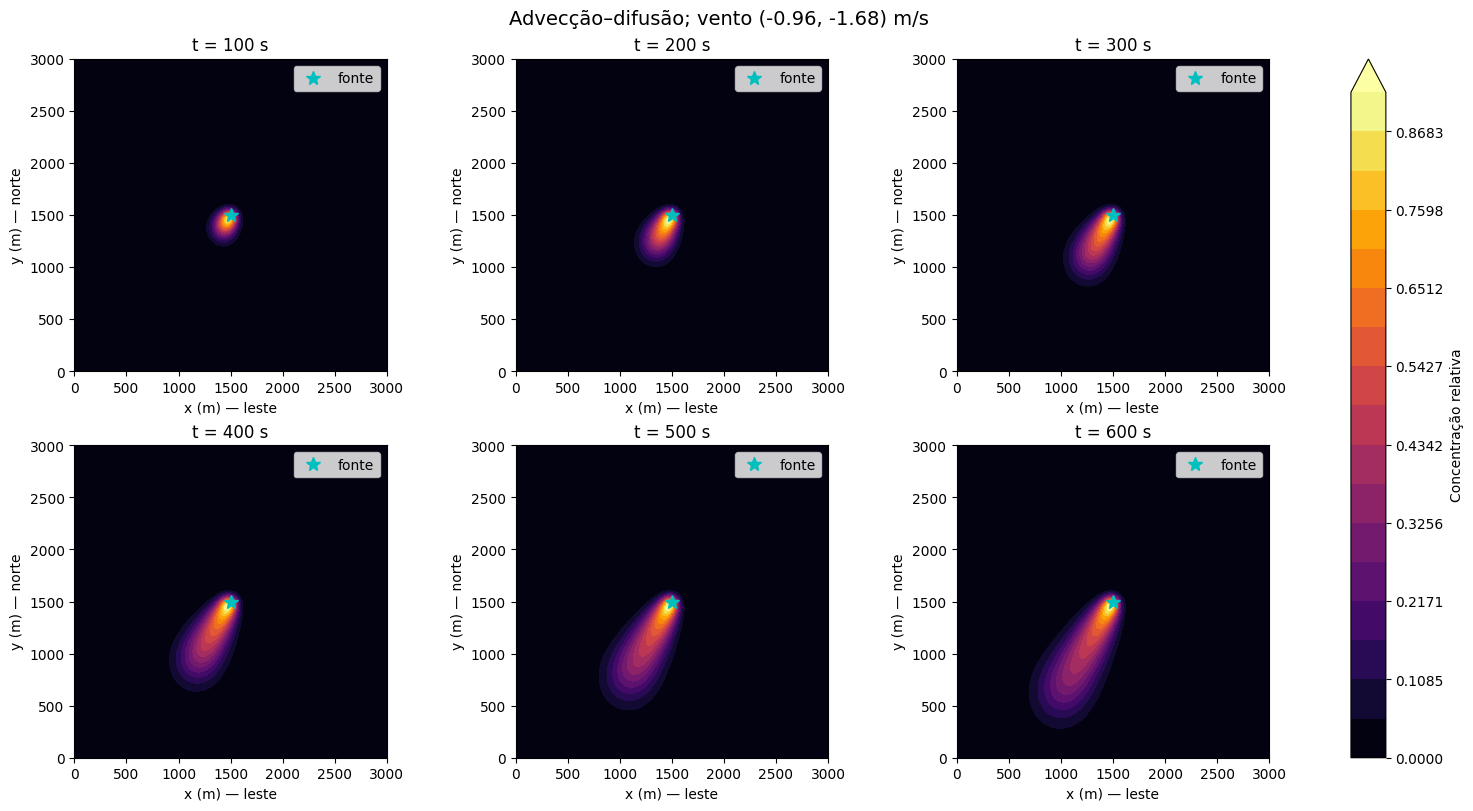

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
levels = np.linspace(0, max(s.max() for s in snapshots), 18)
for ax, t, field in zip(axes.flat, times[1:7], snapshots[1:7]):
    cf = ax.contourf(X, Y, field, levels=levels, cmap="inferno", extend="max")
    ax.plot(source_x, source_y, "c*", markersize=10, label="fonte")
    ax.set_title(f"t = {t:.0f} s")
    ax.set_xlabel("x (m) — leste")
    ax.set_ylabel("y (m) — norte")
    ax.set_aspect("equal")
    ax.legend(loc="upper right")
fig.colorbar(cf, ax=axes, label="Concentração relativa")
fig.suptitle(f"Advecção–difusão; vento ({u10:.2f}, {v10:.2f}) m/s", fontsize=14)
plt.show()

## 7. Animação opcional

A animação mostra o campo calculado ao longo do tempo. Para exportar como GIF em Colab, descomente a última linha; pode ser necessário instalar `pillow`.

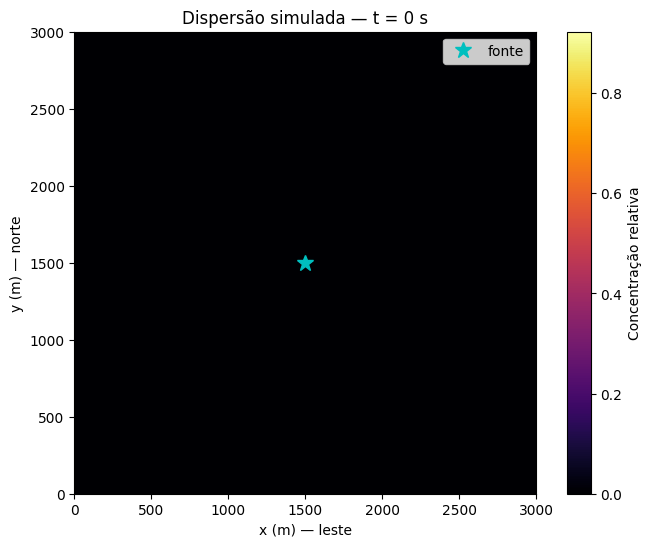

In [38]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

fig, ax = plt.subplots(figsize=(8, 6))
vmax = max(s.max() for s in snapshots)
image = ax.imshow(snapshots[0], origin="lower", extent=[0,Lx,0,Ly],
                  cmap="inferno", vmin=0, vmax=vmax, animated=True)
ax.plot(source_x, source_y, "c*", markersize=12, label="fonte")
ax.set_xlabel("x (m) — leste")
ax.set_ylabel("y (m) — norte")
ax.legend()
title = ax.set_title("t = 0 s")
fig.colorbar(image, ax=ax, label="Concentração relativa")

def update(i):
    image.set_data(snapshots[i])
    title.set_text(f"Dispersão simulada — t = {times[i]:.0f} s")
    return image, title

anim = FuncAnimation(fig, update, frames=len(snapshots), interval=500, blit=False)
display(HTML(anim.to_jshtml()))
# Para salvar como GIF: anim.save("dispersao_pluma.gif", writer="pillow", fps=2)

## 8. Comparar vento de fundo e difusão

Repita a simulação variando (K). Valores maiores espalham a concentração mais rapidamente; a velocidade e a direção do centro da pluma continuam controladas pelo vento. Os valores de (K) são parâmetros ilustrativos, não estimativas observadas para o acidente.

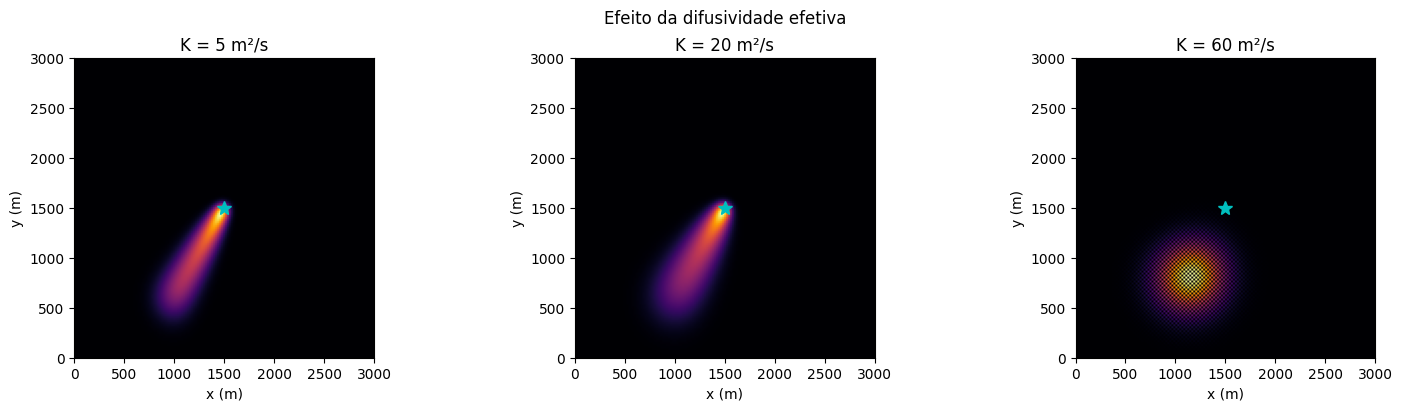

In [39]:
def run_case(K_case, steps=None):
    """Executa um caso e devolve o campo final."""
    c = np.zeros_like(X, dtype=float)
    nrun = n_steps if steps is None else steps
    for _ in range(nrun):
        c = advance(c, u10, v10, K_case, dt, dx, dy, source, source_strength)
    return c

K_values = [5.0, 20.0, 60.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, kval in zip(axes, K_values):
    field = run_case(kval)
    ax.imshow(field, origin="lower", extent=[0,Lx,0,Ly], cmap="inferno")
    ax.plot(source_x, source_y, "c*", markersize=10)
    ax.set_title(f"K = {kval:.0f} m²/s")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
plt.suptitle("Efeito da difusividade efetiva")
plt.show()

Por favor, selecione a foto do acidente. Você pode cancelar se não tiver uma.


Saving pluma.jpeg to pluma (3).jpeg


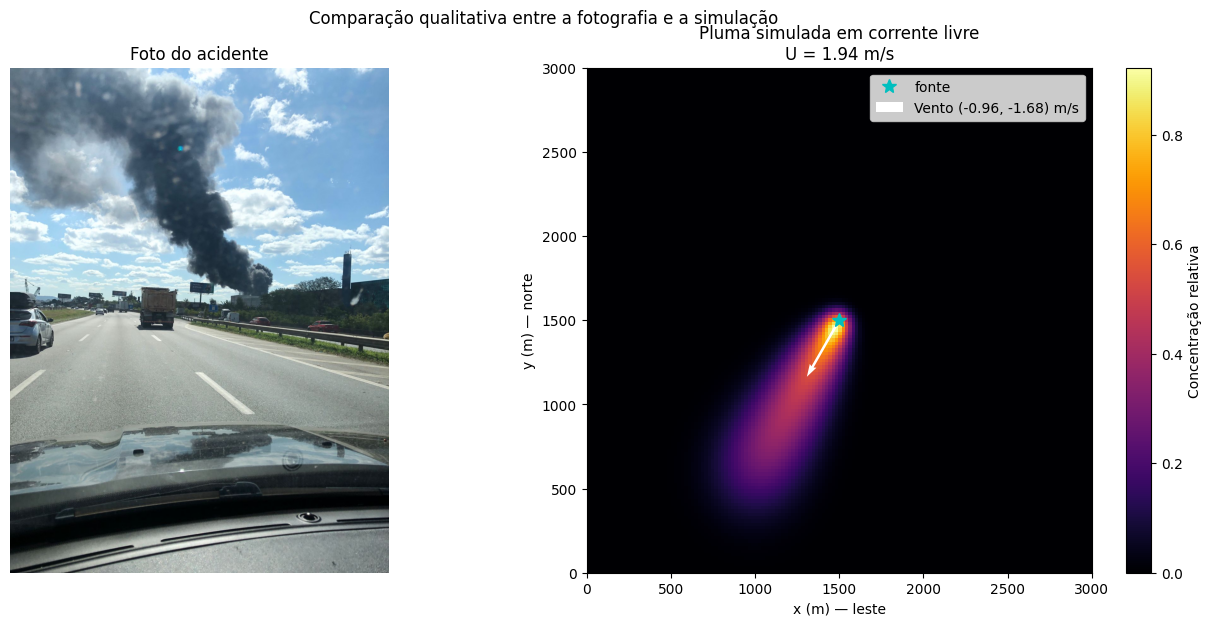

In [40]:
from google.colab import files
from PIL import Image
import io
import matplotlib.pyplot as plt

def desenhar_pluma(ax, wind_u, wind_v, title_text):
    """Desenha a pluma simulada, a fonte e o vetor de vento."""
    vmax = snapshots[-1].max()
    im = ax.imshow(snapshots[-1], origin="lower", extent=[0, Lx, 0, Ly],
                   cmap="inferno", vmin=0, vmax=vmax)
    ax.plot(source_x, source_y, "c*", markersize=10, label="fonte")

    # Adiciona o vetor de vento
    center_x, center_y = Lx / 2, Ly / 2 # Ponto central para o vetor
    scale_factor = 200 # Ajusta o comprimento da seta para visualização

    ax.quiver(center_x, center_y, wind_u, wind_v, color='white',
              scale=1/scale_factor, scale_units='xy', angles='xy', width=0.005,
              label=f'Vento ({wind_u:.2f}, {wind_v:.2f}) m/s')

    ax.set_title(title_text)
    ax.set_xlabel("x (m) — leste")
    ax.set_ylabel("y (m) — norte")
    ax.set_aspect("equal")
    ax.legend(loc="upper right")
    fig.colorbar(im, ax=ax, label="Concentração relativa")


# Selecione a foto do acidente
print("Por favor, selecione a foto do acidente. Você pode cancelar se não tiver uma.")
arquivo_enviado = files.upload()

# Verifica se algum arquivo foi enviado
if arquivo_enviado:
    nome_foto = next(iter(arquivo_enviado))
    foto = Image.open(io.BytesIO(arquivo_enviado[nome_foto]))

    # Comparação visual
    fig, (ax_foto, ax_modelo) = plt.subplots(1, 2, figsize=(14, 6))

    ax_foto.imshow(foto)
    ax_foto.set_title("Foto do acidente")
    ax_foto.axis("off")

    # Usa a função já definida no notebook e o vento calculado a partir dos CSVs
    desenhar_pluma(
        ax_modelo,
        u10, # Passa u10
        v10, # Passa v10
        f"Pluma simulada em corrente livre\nU = {speed:.2f} m/s"
    )

    fig.suptitle("Comparação qualitativa entre a fotografia e a simulação")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma foto foi enviada. Pulando a comparação visual.")

In [41]:
import numpy as np
from PIL import Image

imagem_rgb = np.asarray(foto.convert("RGB"))

# Brilho aproximado em escala de cinza
cinza = (
    0.299 * imagem_rgb[..., 0]
    + 0.587 * imagem_rgb[..., 1]
    + 0.114 * imagem_rgb[..., 2]
)

# máscara: True nos pixels identificados como pluma
brilho_pluma = cinza[mascara].mean()
brilho_fundo = cinza[mascara_fundo].mean()

print(f"Brilho médio da pluma: {brilho_pluma:.1f}/255")
print(f"Brilho médio do fundo: {brilho_fundo:.1f}/255")
print(f"Contraste relativo: {abs(brilho_fundo - brilho_pluma):.1f}/255")

Brilho médio da pluma: 81.5/255
Brilho médio do fundo: 186.3/255
Contraste relativo: 104.8/255


In [42]:
import numpy as np
from PIL import Image

imagem_rgb = np.asarray(foto.convert("RGB"))

# Brilho aproximado em escala de cinza
cinza = (
    0.299 * imagem_rgb[..., 0]
    + 0.587 * imagem_rgb[..., 1]
    + 0.114 * imagem_rgb[..., 2]
)

# Definir máscaras para pluma e fundo com base em um limiar de brilho
# Supondo que a pluma seja geralmente mais escura (menor brilho) e o fundo mais claro
limiar_brilho = 150 # Este valor pode ser ajustado para melhor segmentação
mascara = cinza < limiar_brilho
mascara_fundo = cinza >= limiar_brilho

# Certifique-se de que as máscaras não estão vazias para evitar erros no .mean()
if not mascara.any():
    print("A máscara da pluma está vazia. Ajuste o limiar de brilho ou verifique a imagem.")
elif not mascara_fundo.any():
    print("A máscara do fundo está vazia. Ajuste o limiar de brilho ou verifique a imagem.")
else:
    brilho_pluma = cinza[mascara].mean()
    brilho_fundo = cinza[mascara_fundo].mean()

    print(f"Brilho médio da pluma: {brilho_pluma:.1f}/255")
    print(f"Brilho médio do fundo: {brilho_fundo:.1f}/255")
    print(f"Contraste relativo: {abs(brilho_fundo - brilho_pluma):.1f}/255")

Brilho médio da pluma: 81.5/255
Brilho médio do fundo: 186.3/255
Contraste relativo: 104.8/255


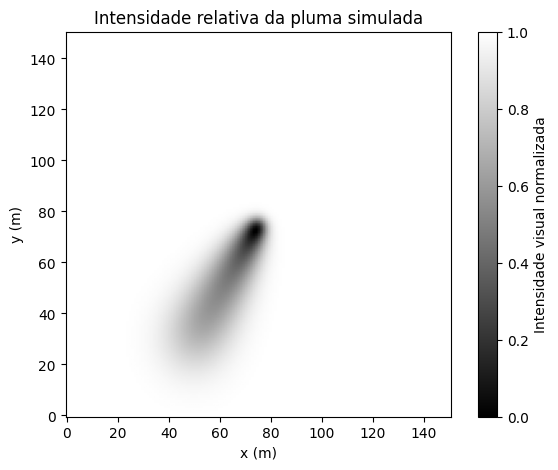

In [43]:
campo = snapshots[-1]
campo_norm = campo / (campo.max() + 1e-12)

# Fumaça mais concentrada aparece mais escura
imagem_simulada = 1.0 - campo_norm

plt.figure(figsize=(7, 5))
plt.imshow(
    imagem_simulada,
    origin="lower",
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Intensidade relativa da pluma simulada")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar(label="Intensidade visual normalizada")
plt.show()

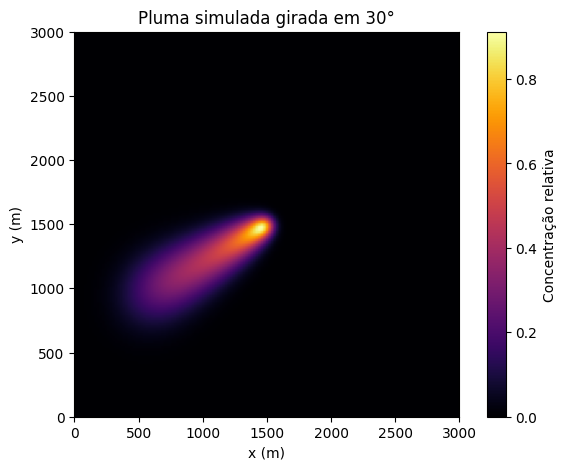

In [44]:
from scipy.ndimage import rotate

angulo_graus = 30  # ajuste até a direção visual coincidir com a foto

campo_alinhado = rotate(
    snapshots[-1],
    angle=angulo_graus,
    reshape=False,
    order=1
)

plt.figure(figsize=(7, 5))
plt.imshow(
    campo_alinhado,
    origin="lower",
    cmap="inferno",
    extent=[0, Lx, 0, Ly]
)
plt.title(f"Pluma simulada girada em {angulo_graus}°")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar(label="Concentração relativa")
plt.show()

Ângulo aparente na foto: 101.8°
Ângulo do vento no modelo: -119.8°
Rotação aplicada à visualização: -138.4°


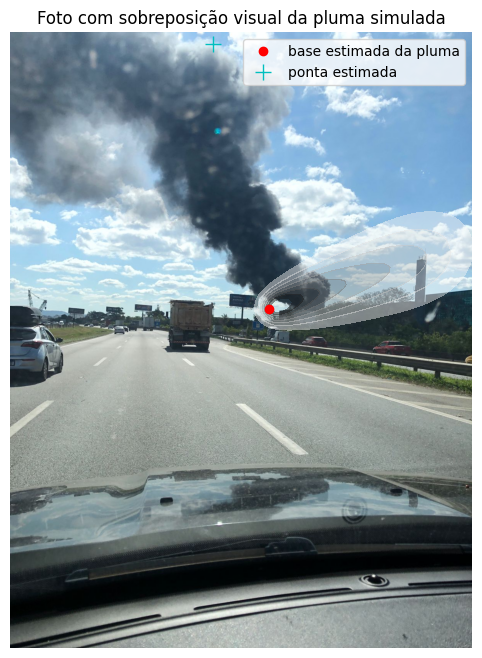

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# Foto em pixels: origem (0, 0) no canto superior esquerdo.
imagem = np.asarray(foto.convert("RGB"))
altura_px, largura_px = imagem.shape[:2]

# Estimativas para esta foto, como frações da largura e da altura.
# Ajuste estes pontos: base da fumaça e ponta da pluma.
base_px = (0.56 * largura_px, 0.45 * altura_px)
ponta_px = (0.44 * largura_px, 0.02 * altura_px)

dx_px = ponta_px[0] - base_px[0]
dy_px = ponta_px[1] - base_px[1]

# O eixo y da foto cresce para baixo; por isso usamos -dy_px.
angulo_foto = np.degrees(np.arctan2(-dy_px, dx_px))

# Direção do vento no modelo: x para leste, y para norte.
angulo_vento = np.degrees(np.arctan2(v10, u10))

# Menor rotação necessária para alinhar os dois ângulos.
rotacao = (angulo_foto - angulo_vento + 180) % 360 - 180
print(f"Ângulo aparente na foto: {angulo_foto:.1f}°")
print(f"Ângulo do vento no modelo: {angulo_vento:.1f}°")
print(f"Rotação aplicada à visualização: {rotacao:.1f}°")

campo_alinhado = rotate(
    snapshots[-1],
    angle=rotacao,
    reshape=False,
    order=1
)

# Escala apenas visual: não representa uma distância calibrada na foto.
pixels_por_metro = 0.45

x_foto = base_px[0] + (X - source_x) * pixels_por_metro
y_foto = base_px[1] - (Y - source_y) * pixels_por_metro

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(imagem, extent=[0, largura_px, altura_px, 0], origin="upper")

# Sobrepõe a concentração simulada em tons escuros e semitransparentes.
niveis = np.linspace(campo_alinhado.max() * 0.12,
                     campo_alinhado.max() * 0.85, 8)

ax.contourf(
    x_foto,
    y_foto,
    campo_alinhado,
    levels=niveis,
    cmap="Greys",
    alpha=0.45
)

ax.plot(*base_px, "ro", label="base estimada da pluma")
ax.plot(*ponta_px, "c+", markersize=12, label="ponta estimada")
ax.set_xlim(0, largura_px)
ax.set_ylim(altura_px, 0)
ax.set_title("Foto com sobreposição visual da pluma simulada")
ax.axis("off")
ax.legend()
plt.show()

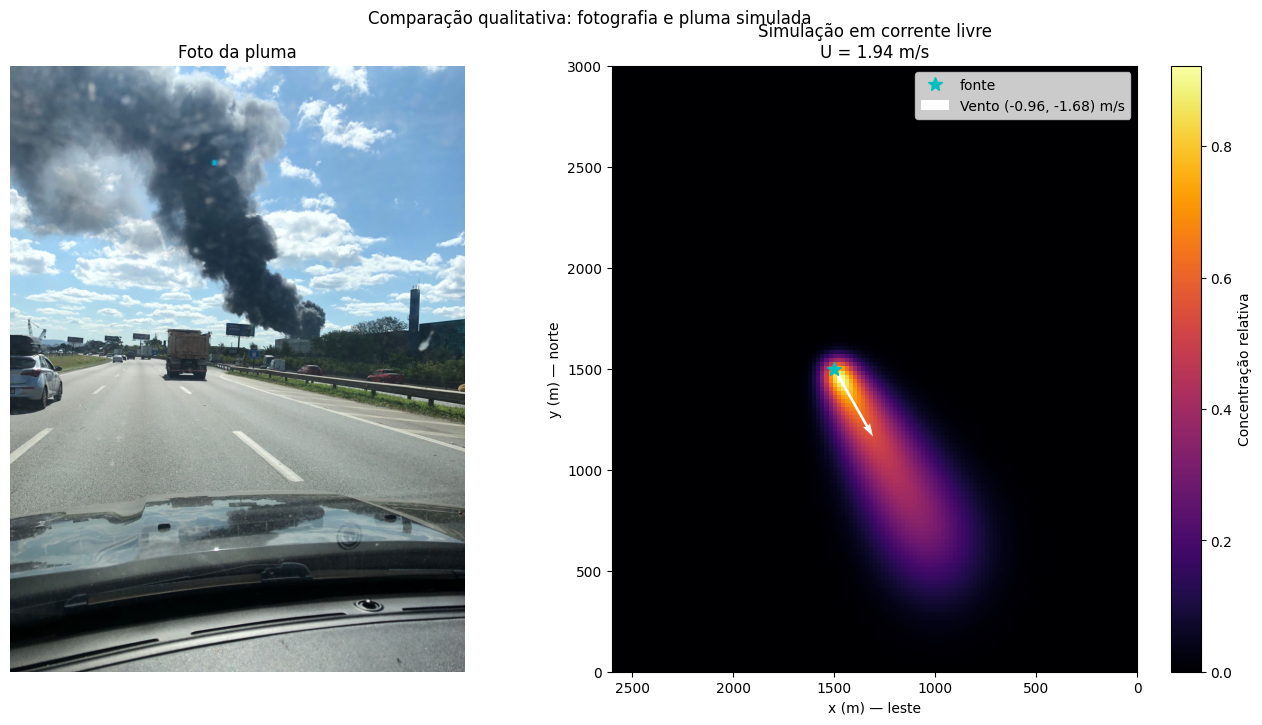

In [46]:
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io

# Envie a foto. Se a variável "foto" já existir, ela será usada.
if "foto" not in globals():
    arquivos = files.upload()

    if not arquivos:
        raise ValueError("Nenhuma foto foi enviada. Execute a célula novamente e selecione a imagem.")

    nome = next(iter(arquivos))
    foto = Image.open(io.BytesIO(arquivos[nome]))

# Cria os dois painéis
fig, (ax_foto, ax_pluma) = plt.subplots(1, 2, figsize=(14, 7))

# Painel esquerdo: fotografia
ax_foto.imshow(foto)
ax_foto.set_title("Foto da pluma")
ax_foto.axis("off")

# Painel direito: ilustração física, com a fumaça visualmente voltada para a esquerda
desenhar_pluma(
    ax_pluma,
    u10, # Passa u10
    v10, # Passa v10
    f"Simulação em corrente livre\nU = {speed:.2f} m/s"
)

# Inverte o eixo horizontal do painel da simulação
ax_pluma.set_xlim(2600, 0)

fig.suptitle("Comparação qualitativa: fotografia e pluma simulada")
plt.tight_layout()
plt.show()

Ângulo aparente na foto: 101.8°
Ângulo do vento no modelo: -119.8°
Rotação aplicada: -138.4°


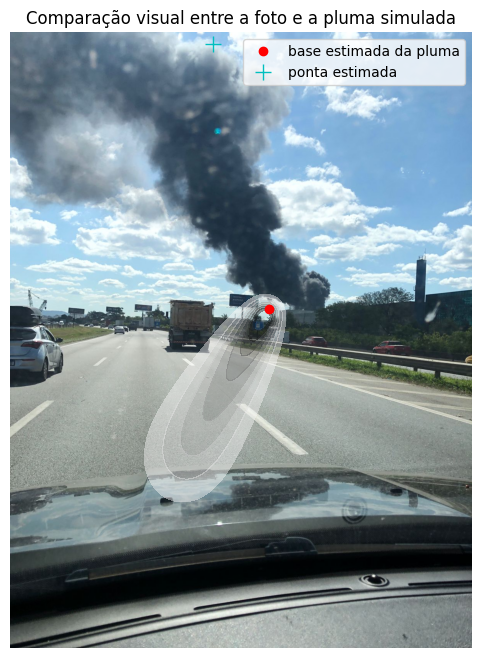

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# Imagem: origem dos pixels no canto superior esquerdo
imagem = np.asarray(foto.convert("RGB"))
altura_px, largura_px = imagem.shape[:2]

# Ajuste estes pontos se necessário: base da fumaça e ponta da pluma
base_px = (0.56 * largura_px, 0.45 * altura_px)
ponta_px = (0.44 * largura_px, 0.02 * altura_px)

# Ângulo da pluma na foto.
# Em pixels, y cresce para baixo; por isso usamos -dy_px.
dx_px = ponta_px[0] - base_px[0]
dy_px = ponta_px[1] - base_px[1]
angulo_foto = np.degrees(np.arctan2(-dy_px, dx_px))

# Ângulo da pluma simulada em relação ao eixo x (leste)
angulo_vento = np.degrees(np.arctan2(v10, u10))

# Rotação necessária para alinhar a simulação à orientação da foto
rotacao = (angulo_foto - angulo_vento + 180) % 360 - 180

print(f"Ângulo aparente na foto: {angulo_foto:.1f}°")
print(f"Ângulo do vento no modelo: {angulo_vento:.1f}°")
print(f"Rotação aplicada: {rotacao:.1f}°")

# Girar o campo e também as coordenadas da malha.
# É importante girar ambos para que o contourf use a orientação corrigida.
campo_alinhado = rotate(
    snapshots[-1],
    angle=rotacao,
    reshape=False,
    order=1
)
X_girado = rotate(X, angle=rotacao, reshape=False, order=1)
Y_girado = rotate(Y, angle=rotacao, reshape=False, order=1)

# Escala visual, sem calibração física
pixels_por_metro = 0.45

x_foto = base_px[0] + (X_girado - source_x) * pixels_por_metro
y_foto = base_px[1] - (Y_girado - source_y) * pixels_por_metro

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(imagem, extent=[0, largura_px, altura_px, 0], origin="upper")

# Sobrepor a concentração simulada à fotografia
limiar = campo_alinhado.max() * 0.12
niveis = np.linspace(limiar, campo_alinhado.max() * 0.85, 8)

ax.contourf(
    x_foto,
    y_foto,
    campo_alinhado,
    levels=niveis,
    cmap="Greys",
    alpha=0.45
)

ax.plot(*base_px, "ro", label="base estimada da pluma")
ax.plot(*ponta_px, "c+", markersize=12, label="ponta estimada")
ax.set_xlim(0, largura_px)
ax.set_ylim(altura_px, 0)
ax.set_title("Comparação visual entre a foto e a pluma simulada")
ax.axis("off")
ax.legend()
plt.show()

In [48]:
!pip -q install ipympl

In [52]:
from google.colab import output
output.enable_custom_widget_manager()

%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

imagem = np.asarray(foto.convert("RGB"))

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(imagem)
ax.set_title("Clique na base da fumaça e, depois, em um ponto da pluma")
ax.axis("on")

pontos = []

def registrar_clique(evento):
    if evento.inaxes != ax or evento.xdata is None or evento.ydata is None:
        return

    pontos.append((evento.xdata, evento.ydata))
    ax.plot(evento.xdata, evento.ydata, "c+", markersize=12)
    fig.canvas.draw_idle()

    if len(pontos) == 1:
        ax.set_title("Agora clique em um ponto mais distante na direção da pluma")
    elif len(pontos) == 2:
        fig.canvas.mpl_disconnect(conexao)
        ax.set_title("Pontos registrados")
        print("Base da pluma:", pontos[0])
        print("Direção da pluma:", pontos[1])

conexao = fig.canvas.mpl_connect("button_press_event", registrar_clique)
plt.show()

ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

imagem = np.asarray(foto.convert("RGB"))
altura_px, largura_px = imagem.shape[:2]

# Clique 1: centro aproximado da fonte de fumaça.
# Clique 2: um ponto mais distante, ao longo da pluma.
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(imagem)
ax.set_title("Clique na fonte da fumaça e depois na direção da pluma")
ax.axis("on")

pontos = plt.ginput(2, timeout=0)
plt.close(fig)

if len(pontos) != 2:
    raise ValueError("Foram necessários dois cliques: fonte e direção da pluma.")

base_px = np.array(pontos[0])   # (x, y) em pixels
ponta_px = np.array(pontos[1])

print("Fonte (pixels):", base_px)
print("Direção indicada (pixels):", ponta_px)

## 9. Interpretar o resultado e limitações

- Com (u<0) e (v<0), o centro da pluma é transportado para sudoeste no plano cartesiano adotado.
- A difusão alarga a distribuição em torno dessa trajetória.
- O campo é concentração relativa; não está em ppm, mg/m³ ou outra unidade física.
- A foto não foi usada para calibrar escala, altura, emissão nem orientação da câmera. Uma máscara YOLO segmenta pixels, mas não fornece automaticamente distância física.
- Para uma reconstrução física seriam necessários dados meteorológicos horários e locais, taxa e temperatura de emissão, altura da fonte, estabilidade atmosférica, rugosidade/obstáculos e observações calibradas.

### Exercícios sugeridos
1. Inverta o sinal de (u) e descreva a mudança na trajetória.
2. Compare (K=5,20,60\,\mathrm{m^2/s}). Como muda a largura e o pico da pluma?
3. Desloque a fonte para outro ponto do domínio e investigue se a pluma alcança a borda.
4. Reduza `dt` pela metade e compare o campo final para avaliar sensibilidade numérica.
5. Explique por que a direção aparente na foto não pode ser comparada diretamente com as direções geográficas sem orientação da câmera.